# Notebook de Entrenamiento: Reconocimiento Facial

## Equipo
- Alumno 1: Juan Andres Morales
- Alumno 2: Genaro Canciani

## 1. Configuración e Instalación
Instalamos las librerías necesarias para el preprocesamiento y entrenamiento.

In [1]:
# import subprocess, sys
# subprocess.run([
#     "uv", "pip", "install",
#     "torch", "torchvision", "torchaudio",
#     "--index-url", "https://download.pytorch.org/whl/cu124",
#     "--upgrade"
# ], check=True)

In [2]:
# --- 1. Utilidades del Sistema y General ---
import os
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import warnings
from pydantic import functional_validators
import sys
from types import ModuleType


# --- 2. Procesamiento de Imágenes y Rostros ---
import cv2
from insightface.app import FaceAnalysis
from insightface.utils import face_align

# --- 3. Deep Learning (PyTorch) ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch.nn.functional as F

# --- 4. Machine Learning y Evaluación ---
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
# print(torch.__version__)               
# print(torch.cuda.is_available())       
# print(torch.cuda.get_device_name(0))   

## 2. Descarga del Dataset LFW
Descargamos el dataset Labeled Faces in the Wild, filtrando aquellas personas que tengan al menos 20 imágenes para asegurar suficientes datos de entrenamiento por clase. Se elige tener un total de 62 personas con exactamente 20 imágenes cada una. Esto permite que el ajuste fino del modelo se haga con datos balanceados y que además cuentan con la variedad suficiente como para que el modelo aprenda representaciones generales de los rostros. 

Descargando LFW...

--- Resumen del Dataset ---
Total de imágenes: 1240
Cantidad real de personas encontradas: 62
Imágenes por persona: 20


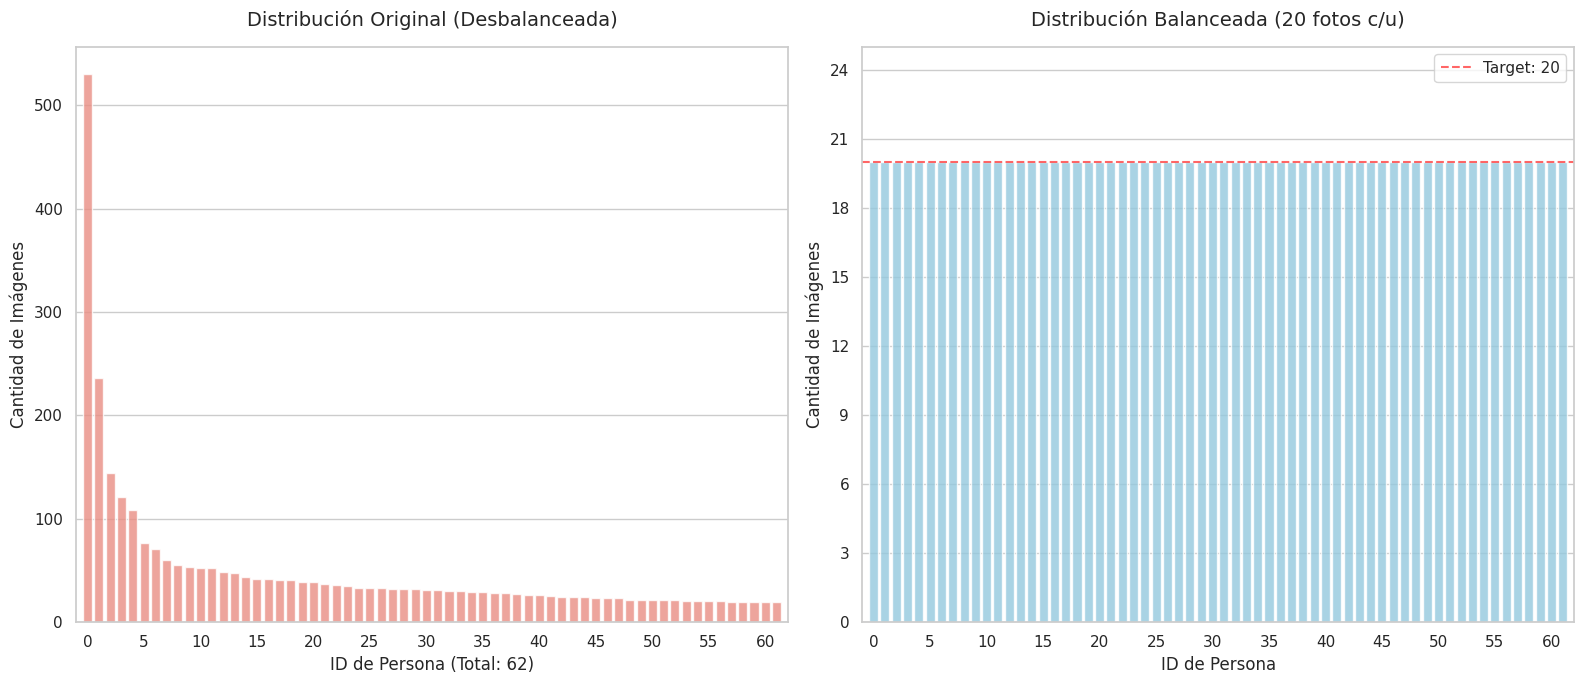

In [4]:
# 1. Parámetros de configuración
n_images_per_person = 20
max_people_request = 70 # Intentaremos buscar hasta 70

# 2. Descarga del dataset
print("Descargando LFW...")
lfw_raw = fetch_lfw_people(min_faces_per_person=n_images_per_person, resize=1.0, color=True, slice_=None)
X_raw = lfw_raw.images
y_raw = lfw_raw.target
target_names = lfw_raw.target_names

# 3. Lógica de balanceo
balanced_images = []
balanced_labels = []
final_names = []

unique, counts = np.unique(y_raw, return_counts=True)
sorted_indices = np.argsort(counts)[::-1]

people_count = 0
for idx in sorted_indices:
    if people_count >= max_people_request:
        break
    
    indices = np.where(y_raw == unique[idx])[0]
    np.random.seed(42)
    selected_indices = np.random.choice(indices, n_images_per_person, replace=False)
    
    balanced_images.append(X_raw[selected_indices])
    balanced_labels.extend([people_count] * n_images_per_person)
    final_names.append(target_names[unique[idx]])
    people_count += 1

# Convertimos a arrays finales
all_images_lfw = np.vstack(balanced_images)
all_labels_lfw = np.array(balanced_labels)
all_target_names_lfw = final_names

# Calculamos el número real de personas encontradas para ajustar el gráfico
actual_num_people = len(final_names)

print(f"\n--- Resumen del Dataset ---")
print(f"Total de imágenes: {len(all_images_lfw)}")
print(f"Cantidad real de personas encontradas: {actual_num_people}")
print(f"Imágenes por persona: {n_images_per_person}")

# 4. Visualización de resultados (Ajustada dinámicamente)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 7))

# Gráfico Izquierdo: Distribución Original
plt.subplot(1, 2, 1)
original_counts = counts[sorted_indices[:actual_num_people]]
sns.barplot(x=list(range(actual_num_people)), y=original_counts, color='salmon', alpha=0.8)
plt.title("Distribución Original (Desbalanceada)", fontsize=14, pad=15)
plt.xlabel(f"ID de Persona (Total: {actual_num_people})", fontsize=12)
plt.ylabel("Cantidad de Imágenes", fontsize=12)
plt.xticks(np.arange(0, actual_num_people, 5))
plt.xlim(-1, actual_num_people) # Elimina espacio extra a los lados

# Gráfico Derecho: Distribución Balanceada
ax2 = plt.subplot(1, 2, 2)
balanced_counts_plot = [n_images_per_person] * actual_num_people
sns.barplot(x=list(range(actual_num_people)), y=balanced_counts_plot, color='skyblue', alpha=0.8)
plt.axhline(n_images_per_person, color='red', linestyle='--', alpha=0.6, label=f'Target: {n_images_per_person}')
plt.title(f"Distribución Balanceada ({n_images_per_person} fotos c/u)", fontsize=14, pad=15)
plt.xlabel("ID de Persona", fontsize=12)
plt.ylabel("Cantidad de Imágenes", fontsize=12)
plt.xticks(np.arange(0, actual_num_people, 5))
plt.xlim(-1, actual_num_people) # Elimina espacio extra a los lados
plt.ylim(0, n_images_per_person + 5)
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.legend()
plt.tight_layout()
plt.show()

Se observa en el gráfico de arriba la gran diferencia entre la cantidad de imágenes de cada clase. A la derecha se ve como el procesamiento aplicado logra general un balance total, contando con exactamente la misma cantidad de imágenes para cada persona. 

## 3. Preprocesamiento (Alineación con InsightFace)
**Justificación:** Extraemos únicamente la zona del rostro y lo alineamos usando los landmarks de InsightFace o un fallback de bounding box si los landmarks fallan. Esto reduce el ruido de fondo y garantiza que la red se enfoque puramente en la identidad facial, siendo robusto a las limitaciones de detección del hardware. Se elige usar RetinaFace por sobre otros modelos de detección facial por su alta precisión en comparación con otros detectores como MTCNN, Yunet, entre otros. El siguiente artículo muestra una comparación a detalle de los diferentes modelos de detección de rostros más usados actualmente: [What's the best face detector?](https://medium.com/pythons-gurus/what-is-the-best-face-detector-ab650d8c1225)


In [5]:
# --- 1. Inicialización de InsightFace ---
print("Inicializando InsightFace para alineación...")
# Nota: Si estás en Colab con GPU, 'CUDAExecutionProvider' es lo correcto.
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0)

def safe_crop_face(img_bgr, face):
    """Realiza el recorte y alineación del rostro detectado."""
    if face.kps is not None:
        aligned = face_align.norm_crop(img_bgr, landmark=face.kps, image_size=112)
        if aligned is not None and aligned.size > 0:
            return aligned
    
    if face.bbox is not None:
        x1, y1, x2, y2 = face.bbox.astype(int)
        h, w = img_bgr.shape[:2]
        x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size > 0:
            return cv2.resize(crop, (112, 112))
    return None

# --- 2. Lógica de procesamiento sobre el set BALANCEADO ---
# Usamos nombres de archivos distintos para no mezclar con el dataset desbalanceado
procesado_img_path = 'lfw_balanced_aligned_images.npy'
procesado_lbl_path = 'lfw_balanced_aligned_labels.npy'

if os.path.exists(procesado_img_path) and os.path.exists(procesado_lbl_path):
    print("¡Archivos encontrados! Cargando LFW balanceado y alineado desde el disco...")
    clean_images = list(np.load(procesado_img_path))
    clean_labels = list(np.load(procesado_lbl_path))
    print(f"Dataset cargado: {len(clean_images)} imágenes de {len(np.unique(clean_labels))} personas.")

else:
    print("No se encontraron archivos procesados. Iniciando alineación de InsightFace...")
    clean_images = []
    clean_labels = []

    # Iteramos sobre el dataset balanceado que creamos en la celda anterior
    n_balanced = len(all_images_lfw)
    
    for i in tqdm(range(n_balanced)):
        # 1. Convertir de float [0,1] a uint8 [0,255] si es necesario
        img_raw = all_images_lfw[i]
        if img_raw.max() <= 1.0:
            img_rgb = (img_raw * 255).astype(np.uint8)
        else:
            img_rgb = img_raw.astype(np.uint8)
            
        # 2. InsightFace requiere BGR
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        
        # 3. Detección y Alineación
        faces = app.get(img_bgr)
        if len(faces) > 0:
            # Tomamos la cara con mayor puntaje de detección
            face = sorted(faces, key=lambda x: x.det_score, reverse=True)[0]
            aligned_face_bgr = safe_crop_face(img_bgr, face)
            
            if aligned_face_bgr is not None:
                aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                clean_images.append(aligned_face_rgb)
                clean_labels.append(all_labels_lfw[i])

    print(f"\nProcesamiento completado: {len(clean_images)} imágenes alineadas de {n_balanced} originales.")
    
    # 4. Guardar para evitar procesar de nuevo
    print("Guardando en disco...")
    np.save(procesado_img_path, np.array(clean_images))
    np.save(procesado_lbl_path, np.array(clean_labels))
    print("¡Listo!")

Inicializando InsightFace para alineación...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0


2026-05-05 17:28:28.606396162 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-face-recognition-app/.venv/lib/python3.12/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory

2026-05-05 17:28:29.019162644 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-face-recognition-app/.venv/lib/python3.12/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libc

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
¡Archivos encontrados! Cargando LFW balanceado y alineado desde el disco...


2026-05-05 17:28:29.312525571 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-face-recognition-app/.venv/lib/python3.12/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory



Dataset cargado: 1237 imágenes de 62 personas.


### Dataset Propio
Procesamos nuestro dataset propio usando la misma lógica de recorte robusto.

In [6]:
warnings.filterwarnings("ignore", category=FutureWarning)

custom_data_path = Path("src/data/dataset_propio") 
custom_images = []
custom_labels = []

# Empezamos el ID de etiquetas después de las clases de LFW balanceado
current_label_id = len(all_target_names_lfw) 
custom_target_names = []

if custom_data_path.exists():
    print(f"Procesando dataset propio (empezando desde ID {current_label_id})...")
    
    # Obtenemos la lista de carpetas
    person_folders = [f for f in custom_data_path.iterdir() if f.is_dir()]
    
    for person_folder in tqdm(person_folders, desc="Procesando personas"):
        person_name = person_folder.name
        custom_target_names.append(person_name)
        
        archivos = []
        for ext in ["*.jpg", "*.png", "*.jpeg", "*.JPG", "*.PNG", "*.JPEG"]:
            archivos.extend(list(person_folder.glob(ext)))
        
        for img_path in archivos:
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None: continue
            
            faces = app.get(img_bgr)
            if len(faces) > 0:
                face = sorted(faces, key=lambda x: x.det_score, reverse=True)[0]
                aligned_face_bgr = safe_crop_face(img_bgr, face)
                
                if aligned_face_bgr is not None:
                    aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                    custom_images.append(aligned_face_rgb)
                    custom_labels.append(current_label_id)
        
        current_label_id += 1
            
    print(f" Dataset propio procesado: {len(custom_images)} imágenes.")
else:
    print(" No se encontró la carpeta del dataset propio.")

# --- UNIÓN FINAL ---
all_images = clean_images + custom_images
all_labels = clean_labels + custom_labels
all_target_names = all_target_names_lfw + custom_target_names

print(f"\n--- RESUMEN FINAL ---")
print(f"Total imágenes: {len(all_images)}")
print(f"Total clases: {len(all_target_names)}")

Procesando dataset propio (empezando desde ID 62)...


Procesando personas:   0%|          | 0/9 [00:00<?, ?it/s]

 Dataset propio procesado: 64 imágenes.

--- RESUMEN FINAL ---
Total imágenes: 1301
Total clases: 71


## 4. Dataloaders y Data Augmentation
Agregamos Data Augmentation (Flip, Rotación, ColorJitter) para aumentar la diversidad de las caras de nuestro dataset propio y reducir el sobreajuste (overfitting). Utilizamos las medias y desviaciones estándar requeridas por los modelos pre-entrenados en ImageNet, puesto que se ajustará mas adelante un modelo de ResNet50, cuyas imágenes de entrenamiento estaban normalizadas exactamente con esos valores. Esta normalización garantiza un ajuste más estable y con menores probabilidades de divergencia. 
Los cambios de normalización se aplican tanto al dataset de Train como al de Validación, pero al único al que se le hace augmentation es al Train. Esto para evitar introducir ruido innecesario en el dataset de validación, lo cuál podría alterar las métricas del modelo. 

Dataset listo. Entrenamiento: 1040 | Validación: 261


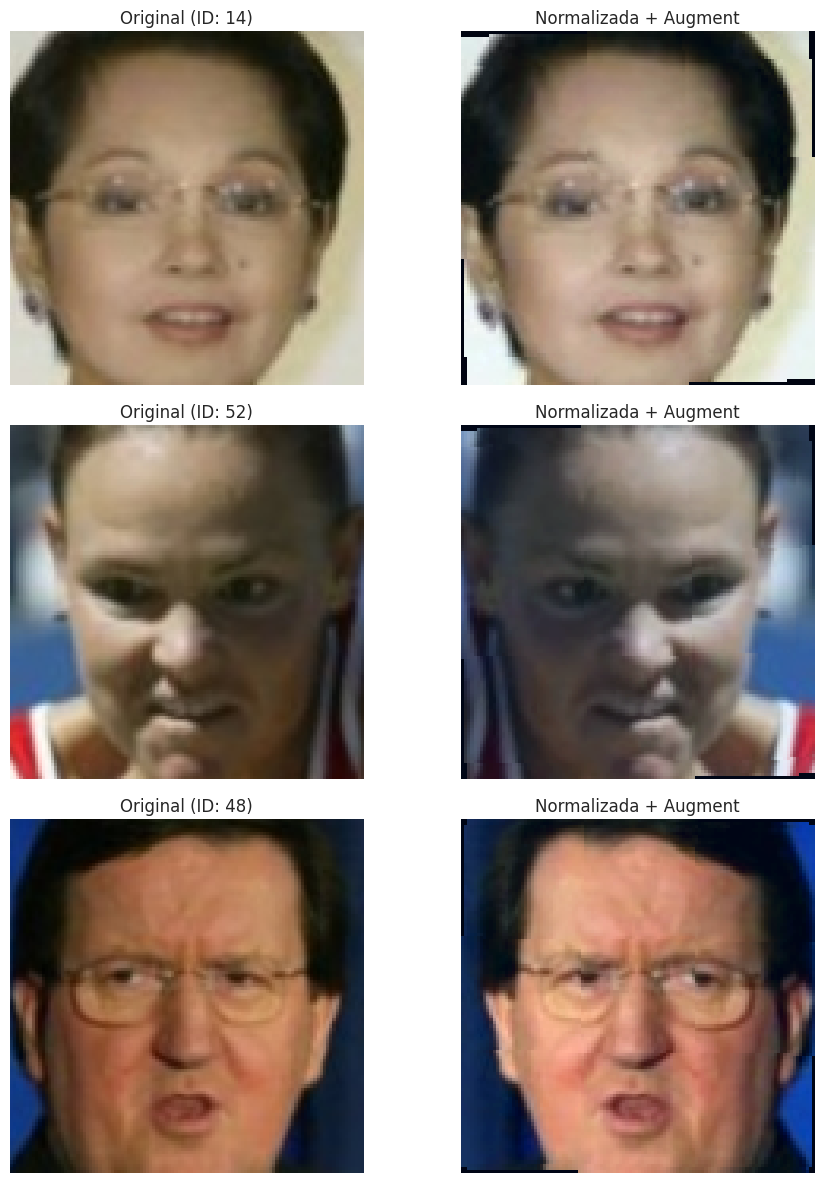

In [7]:
# 1. Definición de la Clase Dataset
class FaceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label

# 2. Definición de Transformaciones
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Split de Datos
X_train, X_val, y_train, y_val = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
val_dataset = FaceDataset(X_val, y_val, transform=val_transform)

# 4. Creación de DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset listo. Entrenamiento: {len(train_dataset)} | Validación: {len(val_dataset)}")

# --- 5. VISUALIZACIÓN DE VARIOS EJEMPLOS ---
def show_multiple_comparisons(n_examples=3):
    plt.figure(figsize=(10, 4 * n_examples))
    
    for i in range(n_examples):
        # Seleccionamos un índice aleatorio cada vez que corras la celda
        idx = np.random.randint(0, len(X_train))
        
        img_orig = X_train[idx]
        img_transformed, label = train_dataset[idx]
        
        # Subplot Original
        plt.subplot(n_examples, 2, 2*i + 1)
        plt.imshow(img_orig)
        plt.title(f"Original (ID: {label})")
        plt.axis('off')
        
        # Subplot Transformada
        plt.subplot(n_examples, 2, 2*i + 2)
        # Re-escalamos solo para que sea visible en el gráfico
        img_np = img_transformed.permute(1, 2, 0).numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        plt.imshow(img_np)
        plt.title("Normalizada + Augment")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Mostramos 3 ejemplos aleatorios
show_multiple_comparisons(n_examples=3)

# 5. Definición de ArcFace

Se decide usar ArcFace como función de pérdida por su capacidad de separar los embeddings de las diferentes clases de manera mucho más precisa que otras funciones de error. Además, es una función específicamente diseñada para trabajar con modelos de identificación facial, por lo que da resultados mucho mejores para este tipo de trabajos. El siguiente artículo describe en profundidad el funcionamiento y las ventajas de esta función: [ArcFace Loss Function for Deep Face Recognition.](https://medium.com/@payyavulasaiprakash/arcface-loss-function-for-deep-face-recognition-e1ff5e173b52)


In [8]:
class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2).clamp(0, 1))
        
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        output *= self.s
        return output

## 6. Arquitectura del Modelo (ResNet50 + Fine Tuning)
Seleccionamos ResNet50 como backbone extractor de características, aprovechando sus pesos pre-entrenados (Transfer Learning) para una convergencia rápida y evitar el sobreajuste. Sin embargo, reemplazamos la clásica capa lineal de clasificación por un módulo ArcFace (Additive Angular Margin Loss). Mientras que la pérdida de entropía cruzada estándar (Cross-Entropy) agrupa las clases de forma débil, ArcFace impone un estricto margen angular matemático entre las distintas identidades durante el entrenamiento. Esto fuerza a la red a agrupar los rostros de una misma persona de forma extremadamente compacta (intra-class compactness) y a alejar radicalmente los clusters de personas diferentes en el espacio latente (inter-class discrepancy). El resultado final es un modelo que extrae embeddings de 512 dimensiones altamente discriminativos, reduciendo drásticamente los falsos positivos y siendo ideal para sistemas de reconocimiento facial de conjunto abierto (Open-Set).

In [13]:
from torchvision import models

class FaceRecognitionMobileNet(nn.Module):
    def __init__(self):
        super(FaceRecognitionMobileNet, self).__init__()
        # MobileNetV3 Large: la versión más moderna de MobileNet en torchvision.
        # Más eficiente que ResNet50 con resultados competitivos.
        self.backbone = models.mobilenet_v3_large(weights='DEFAULT')
        
        # En MobileNetV3, classifier[0] es un Linear(960, 1280).
        # Tomamos el in_features del primer linear del classifier original (960).
        num_ftrs = self.backbone.classifier[0].in_features
        
        # Reemplazamos todo el classifier por nuestra cabeza de embedding.
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.BatchNorm1d(512),
            nn.PReLU(),  # Conserva valores negativos: mejor para hiperesfera de embeddings
            nn.Dropout(0.5)
        )
        
    def forward(self, x):
        # 1. Pasar por el backbone (features + avgpool + classifier custom)
        x = self.backbone(x)
        # 2. Normalización L2 (obligatoria para ArcFace y búsqueda vectorial)
        return torch.nn.functional.normalize(x, p=2, dim=1)
        
    def extract_embedding(self, x):
        # En inferencia usamos el mismo forward
        return self.forward(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model = FaceRecognitionMobileNet()
model = model.to(device)

# Inicializamos ArcFace
arcface = ArcFace(in_features=512, out_features=len(all_target_names), s=30.0, m=0.50)
arcface = arcface.to(device)

print(f"Modelo MobileNetV3 Large cargado exitosamente para {len(all_target_names)} clases.")


Usando dispositivo: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /home/gena/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:01<00:00, 11.3MB/s]


Modelo MobileNetV3 Large cargado exitosamente para 71 clases.


## 7. Bucle de Entrenamiento (Training Loop)
Ajustamos los pesos del modelo. Usamos `ArcFace` y el optimizador `Adam`.En este caso se realiza un Fine Tuning de la arquitectura completa para que el modelo (previamente entrenado con ImageNet, no para la detección facial) pueda adaptarse a extraer características de rostros. Se toma la decisión de utilizar un lr de 1e-4 para no destruir las características generales ya aprendidas por el modelo. 

La poca cantidad de épocas se debe a la rápida convergencia del modelo, logrando alcanzar una accuracy en validación de 92% en la primera iteración del loop de entrenamiento. 

In [10]:
# 1. Configuración de Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 2. Pérdida y Optimización
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.parameters()},
    {'params': arcface.parameters()}
], lr=0.0001)

# Scheduler para reducir el LR si el entrenamiento se estanca
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 20
best_val_acc = 0.0

print("Iniciando entrenamiento optimizado para ArcFace...")
print(f"Dataset de entrenamiento: {len(train_loader.dataset)} imágenes")
print(f"Dataset de validación: {len(val_loader.dataset)} imágenes\n")

for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    arcface.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # Forward pass con margen para la pérdida
        embeddings = model(inputs)
        outputs = arcface(embeddings, labels)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Cálculo de Accuracy (usamos similitud coseno pura, sin margen)
        with torch.no_grad():
            # Comparamos embeddings normalizados contra pesos normalizados
            logits = F.linear(F.normalize(embeddings), F.normalize(arcface.weight))
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
    train_acc = 100 * train_correct / train_total
    
    # --- FASE DE VALIDACIÓN ---
    model.eval()
    arcface.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            embeddings = model(inputs)
            # Para validación, calculamos pérdida CON margen pero predicción SIN margen
            outputs_with_margin = arcface(embeddings, labels)
            loss = criterion(outputs_with_margin, labels)
            val_loss += loss.item()
            
            # Predicción pura (Similitud Coseno)
            logits = F.linear(F.normalize(embeddings), F.normalize(arcface.weight))
            _, predicted = torch.max(logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)
    epoch_time = time.time() - start_time
    
    # Obtener el LR actual para el log
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Época [{epoch+1}/{num_epochs}] - {epoch_time:.0f}s - LR: {current_lr:.6f}")
    print(f"  TRAIN -> Loss: {running_loss/len(train_loader):.4f} | Acc: {train_acc:.2f}%")
    print(f"  VAL   -> Loss: {avg_val_loss:.4f} | Acc: {val_acc:.2f}%")
    
    # Actualizar Scheduler
    scheduler.step(avg_val_loss)
    
    # Guardar el mejor modelo basado en precisión de validación
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs("models", exist_ok=True)
        torch.save(model.state_dict(), 'models/face_recognition_best.pth')
        print(f"   ¡Nuevo récord de validación! Guardado: {best_val_acc:.2f}%")
    print("-" * 30)

print(f"\nEntrenamiento finalizado. Mejor precisión en validación: {best_val_acc:.2f}%")

Iniciando entrenamiento optimizado para ArcFace...
Dataset de entrenamiento: 1040 imágenes
Dataset de validación: 261 imágenes

Época [1/20] - 31s - LR: 0.000100
  TRAIN -> Loss: 19.2775 | Acc: 2.25%
  VAL   -> Loss: 18.8891 | Acc: 8.05%
   ¡Nuevo récord de validación! Guardado: 8.05%
------------------------------
Época [2/20] - 31s - LR: 0.000100
  TRAIN -> Loss: 18.3513 | Acc: 11.91%
  VAL   -> Loss: 18.1728 | Acc: 18.77%
   ¡Nuevo récord de validación! Guardado: 18.77%
------------------------------
Época [3/20] - 32s - LR: 0.000100
  TRAIN -> Loss: 17.3902 | Acc: 28.61%
  VAL   -> Loss: 17.2135 | Acc: 30.65%
   ¡Nuevo récord de validación! Guardado: 30.65%
------------------------------
Época [4/20] - 31s - LR: 0.000100
  TRAIN -> Loss: 16.3095 | Acc: 46.68%
  VAL   -> Loss: 16.3530 | Acc: 39.46%
   ¡Nuevo récord de validación! Guardado: 39.46%
------------------------------
Época [5/20] - 31s - LR: 0.000100
  TRAIN -> Loss: 15.1541 | Acc: 61.72%
  VAL   -> Loss: 15.1859 | Acc: 50

## 7. Evaluación: Métricas y Embeddings (PCA / t-SNE)
Validamos que el modelo haya aprendido a separar las identidades en el espacio vectorial.

In [11]:
model.eval()
arcface.eval() # Asegurarnos de poner arcface en eval también
all_preds = []
all_labels_val = []
all_embeddings = []

with torch.no_grad():
    # Normalizamos los pesos de las 71 identidades guardadas en ArcFace
    arcface_weights = F.normalize(arcface.weight)
    
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        # Ya no necesitamos labels en GPU para el modelo, solo para guardar el reporte
        
        # 1. El modelo saca los 512 números (el embedding)
        embeddings = model(inputs)
        
        # 2. Calculamos la similitud (producto punto) entre los embeddings y los 71 centros
        # Como ambos están normalizados, esto equivale a la Similitud Coseno pura.
        cosine_sim = F.linear(embeddings, arcface_weights)
        
        # 3. La predicción es simplemente el índice con mayor similitud coseno
        _, predicted = torch.max(cosine_sim, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels_val.extend(labels.numpy())
        all_embeddings.extend(embeddings.cpu().numpy())

# --- Classification Report (Accuracy, Precision, Recall) ---
print("Classification Report:")
print(classification_report(all_labels_val, all_preds, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      1.00      1.00         4
           2       0.67      1.00      0.80         4
           3       1.00      1.00      1.00         4
           4       1.00      0.75      0.86         4
           5       1.00      1.00      1.00         4
           6       1.00      0.75      0.86         4
           7       1.00      1.00      1.00         4
           8       1.00      0.50      0.67         4
           9       1.00      1.00      1.00         4
          10       0.80      1.00      0.89         4
          11       1.00      0.75      0.86         4
          12       1.00      0.75      0.86         4
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         4
          16       0.67      1.00      0.80         4
    

Calculando t-SNE en 2D...


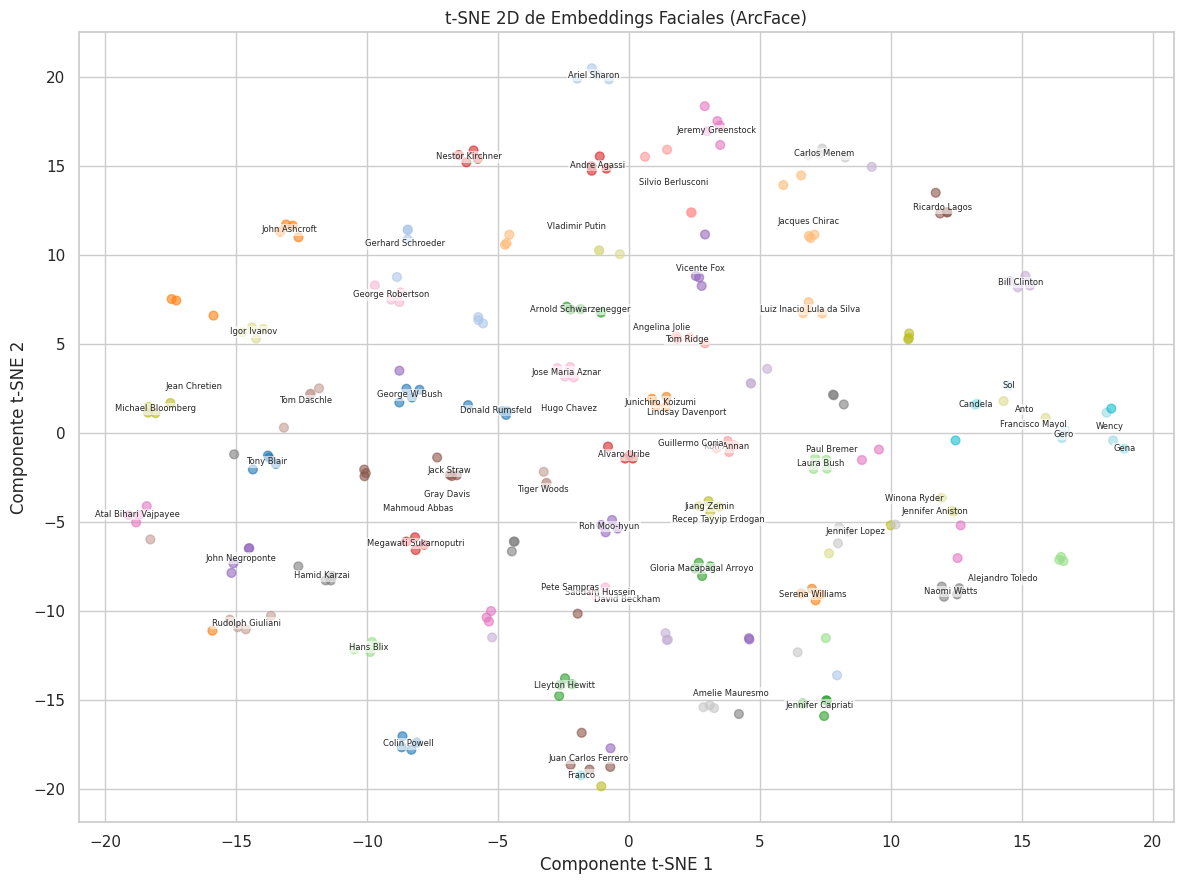

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Convertimos a arrays por las dudas
all_embeddings_np = np.array(all_embeddings)
all_labels_np = np.array(all_labels_val)

print("Calculando t-SNE en 2D...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(all_embeddings_np)

plt.figure(figsize=(12, 9))

# Dibujamos los puntos
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=all_labels_np, cmap='tab20', alpha=0.6, s=40)

# Agregamos los nombres en el centro de cada cluster para saber "quién es quién"
for i in np.unique(all_labels_np):
    idx = all_labels_np == i
    
    # Centro aproximado de los puntos de esta persona
    x_center = np.mean(tsne_result[idx, 0])
    y_center = np.mean(tsne_result[idx, 1])
    
    nombre = all_target_names[i]
    
    # Ponemos el texto con un fondito semi-transparente para que se lea bien
    plt.text(x_center, y_center, nombre, fontsize=6, ha='center', va='center', 
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.title("t-SNE 2D de Embeddings Faciales (ArcFace)")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.tight_layout()
plt.show()